# Manual CZ Optimization

This notebook shows the first supported workflow of the library: manually define Hamiltonian blocks, evaluate a pulse without optimization, optimize one fixed pulse duration, trace selected populations, and run a time-continuation scan.

The CZ example uses three blocks with weights `1, 2, 1`: `|00>`, the one-excitation sector represented by `|1>, |r>`, and the symmetric `|11>, |W>, |rr>` sector.

In [9]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd()
if project_root.name == "examples":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

from time_optimal_grape import (
    AveragePhaseGateFidelity,
    ControlLayout,
    ControlValues,
    GrapeOptimizer,
    GrapeProblem,
    ManualHamiltonianBlock,
    OptimizerSettings,
    TimeContinuationScanner,
    TimeScanSettings,
    assemble_parameters,
    basis_state,
    normalized_state,
    phase_sample_axis,
    random_control_profile,
    trace_populations,
    unwrap_phase_profile,
    zero_control_profile,
)

## Manual Hamiltonian and Fidelity

For each time slice, the control is

$$
\Omega_k = \Omega e^{i\phi_k}.
$$

The one-excitation block is

$$
H_1(\phi_k) = \frac{1}{2}
\begin{pmatrix}
0 & \Omega e^{i\phi_k} \\
\Omega e^{-i\phi_k} & 0
\end{pmatrix}.
$$

For the `|11>` sector we use the symmetric basis `|11>, |W>, |rr>`, where `|W>=(|1r>+|r1>)/\sqrt{2}`. The block is

$$
H_2(\phi_k) =
\begin{pmatrix}
0 & \sqrt{2}\Omega e^{i\phi_k}/2 & 0 \\
\sqrt{2}\Omega e^{-i\phi_k}/2 & 0 & \sqrt{2}\Omega e^{i\phi_k}/2 \\
0 & \sqrt{2}\Omega e^{-i\phi_k}/2 & B
\end{pmatrix}.
$$

The local phase rule is

$$
\xi_{00}=0,\quad \xi_{01}=\xi_{10}=\theta,\quad \xi_{11}=\pi+2\theta.
$$

The optimizer maximizes the averaged phase-gate fidelity. The same API can also evaluate the current infidelity without running optimization.

In [10]:
def make_cz_blocks(omega: float, blockade: float) -> tuple[ManualHamiltonianBlock, ...]:
    def h_zero(control_values: ControlValues, sample_index: int) -> np.ndarray:
        return np.zeros((1, 1), dtype=np.complex128)

    def dh_zero(control_values: ControlValues, sample_index: int) -> np.ndarray:
        return np.zeros((1, 1), dtype=np.complex128)

    def h_one(control_values: ControlValues, sample_index: int) -> np.ndarray:
        phi = control_values.time_controls["phi"][sample_index]
        drive = omega * np.exp(1j * phi) / 2.0
        hamiltonian = np.zeros((2, 2), dtype=np.complex128)
        hamiltonian[0, 1] = drive
        hamiltonian[1, 0] = np.conj(drive)
        return hamiltonian

    def dh_one(control_values: ControlValues, sample_index: int) -> np.ndarray:
        phi = control_values.time_controls["phi"][sample_index]
        drive_derivative = 1j * omega * np.exp(1j * phi) / 2.0
        derivative = np.zeros((2, 2), dtype=np.complex128)
        derivative[0, 1] = drive_derivative
        derivative[1, 0] = np.conj(drive_derivative)
        return derivative

    def h_two(control_values: ControlValues, sample_index: int) -> np.ndarray:
        phi = control_values.time_controls["phi"][sample_index]
        drive = np.sqrt(2.0) * omega * np.exp(1j * phi) / 2.0
        hamiltonian = np.zeros((3, 3), dtype=np.complex128)
        hamiltonian[0, 1] = drive
        hamiltonian[1, 0] = np.conj(drive)
        hamiltonian[1, 2] = drive
        hamiltonian[2, 1] = np.conj(drive)
        hamiltonian[2, 2] = blockade
        return hamiltonian

    def dh_two(control_values: ControlValues, sample_index: int) -> np.ndarray:
        phi = control_values.time_controls["phi"][sample_index]
        drive_derivative = 1j * np.sqrt(2.0) * omega * np.exp(1j * phi) / 2.0
        derivative = np.zeros((3, 3), dtype=np.complex128)
        derivative[0, 1] = drive_derivative
        derivative[1, 0] = np.conj(drive_derivative)
        derivative[1, 2] = drive_derivative
        derivative[2, 1] = np.conj(drive_derivative)
        return derivative

    return (
        ManualHamiltonianBlock(
            name="00",
            weight=1,
            initial_state=basis_state(1, 0),
            target_state=normalized_state((1.0,)),
            hamiltonian=h_zero,
            derivatives={"phi": dh_zero},
            phase_offset=0.0,
            local_phase_coefficients={"theta": 0.0},
        ),
        ManualHamiltonianBlock(
            name="01_or_10",
            weight=2,
            initial_state=basis_state(2, 0),
            target_state=basis_state(2, 0),
            hamiltonian=h_one,
            derivatives={"phi": dh_one},
            phase_offset=0.0,
            local_phase_coefficients={"theta": 1.0},
        ),
        ManualHamiltonianBlock(
            name="11",
            weight=1,
            initial_state=basis_state(3, 0),
            target_state=basis_state(3, 0),
            hamiltonian=h_two,
            derivatives={"phi": dh_two},
            phase_offset=np.pi,
            local_phase_coefficients={"theta": 2.0},
        ),
    )

## Evaluate a Pulse and Optimize One Fixed Duration

All durations in this project are dimensionless. We plot them as $T\Omega$ or $t\Omega$.

In [11]:
samples = 50
duration = 7.6
omega = 1.0
blockade = 10.0

layout = ControlLayout(time_control_names=("phi",), local_phase_names=("theta",), samples=samples)
settings = OptimizerSettings(method="BFGS", max_iterations=400, gradient_tolerance=1e-8, display=False)
problem = GrapeProblem(
    blocks=make_cz_blocks(omega=omega, blockade=blockade),
    control_layout=layout,
    duration=duration,
    objective=AveragePhaseGateFidelity(hilbert_dimension=4),
    optimizer_settings=settings,
)

rng = np.random.default_rng(7)
initial_parameters = assemble_parameters(
    layout=layout,
    time_controls={"phi": random_control_profile(samples=samples, low=-0.05, high=0.05, rng=rng)},
    local_phases={"theta": 0.0},
)
zero_parameters = assemble_parameters(
    layout=layout,
    time_controls={"phi": zero_control_profile(samples=samples)},
    local_phases={"theta": 0.0},
)

initial_infidelity, _initial_gradient = GrapeOptimizer(problem).evaluate(initial_parameters)
zero_infidelity, _zero_gradient = GrapeOptimizer(problem).evaluate(zero_parameters)
print(f"random initial infidelity: {initial_infidelity:.6e}")
print(f"zero-phase infidelity: {zero_infidelity:.6e}")

random initial infidelity: 7.996931e-01
zero-phase infidelity: 7.992973e-01


In [12]:
result = GrapeOptimizer(problem).optimize(initial_parameters)
print(f"success: {result.success}")
print(f"message: {result.message}")
print(f"nominal infidelity: {1.0 - result.fidelity:.6e}")

success: True
message: Optimization terminated successfully.
nominal infidelity: 7.826227e-05


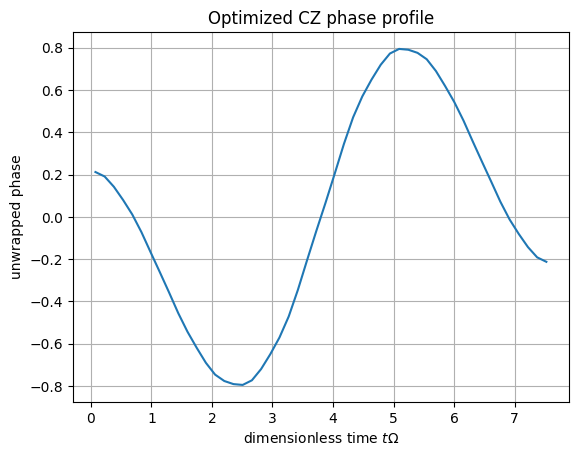

In [13]:
optimized_controls = layout.unpack(result.parameters)
time_axis = phase_sample_axis(duration=duration, samples=samples)
plt.plot(time_axis, unwrap_phase_profile(optimized_controls.time_controls["phi"]))
plt.xlabel(r"dimensionless time $t\Omega$")
plt.ylabel("unwrapped phase")
plt.title("Optimized CZ phase profile")
plt.grid(True)
plt.show()

## Trace Populations

After optimization, we can reuse the same protocol and record populations in selected states of one block. The requested states are supplied explicitly by the user.

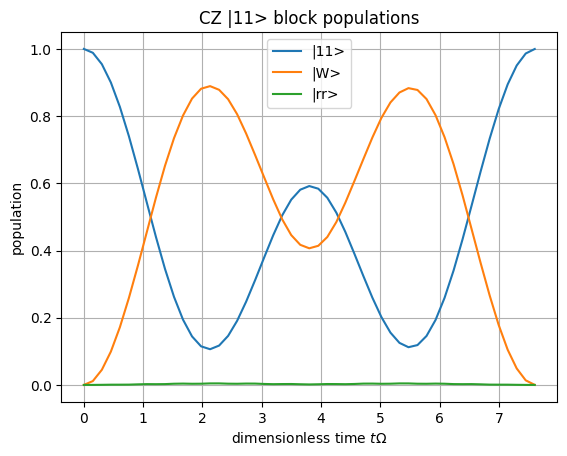

In [14]:
cz_controls = layout.unpack(result.parameters)
block_11 = next(block for block in problem.blocks if block.name == "11")
population_trace = trace_populations(
    block=block_11,
    control_values=cz_controls,
    duration=duration,
    samples=samples,
    states={
        "|11>": basis_state(3, 0),
        "|W>": basis_state(3, 1),
        "|rr>": basis_state(3, 2),
    },
)

for label, values in population_trace.populations.items():
    plt.plot(population_trace.times, values, label=label)
plt.xlabel(r"dimensionless time $t\Omega$")
plt.ylabel("population")
plt.title("CZ |11> block populations")
plt.legend()
plt.grid(True)
plt.show()

## Time-Continuation Scan

The scan starts from a longer duration and uses each optimized pulse as the initial guess for the next shorter duration. The plot is sorted so that $T\Omega$ increases from left to right.

T*Omega=7.900, infidelity=8.548717e-15
T*Omega=7.850, infidelity=1.443290e-15
T*Omega=7.800, infidelity=-1.776357e-15
T*Omega=7.750, infidelity=2.331468e-15
T*Omega=7.700, infidelity=2.331468e-15
T*Omega=7.650, infidelity=0.000000e+00
T*Omega=7.600, infidelity=7.826227e-05
T*Omega=7.550, infidelity=4.094944e-04
T*Omega=7.500, infidelity=9.952038e-04
T*Omega=7.450, infidelity=1.829771e-03


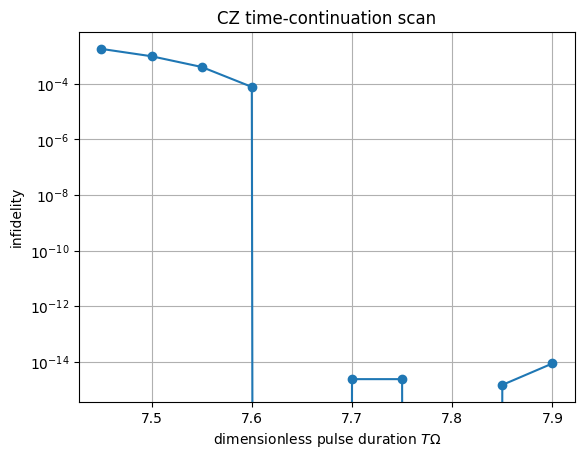

In [20]:
scan_settings = TimeScanSettings(
    start_duration=7.9,
    stop_duration=6.0,
    duration_step=0.05,
    infidelity_threshold=1e-3,
    stop_after_threshold_failure=True,
)
scan_problem = problem.with_duration(scan_settings.start_duration)
scan_points = TimeContinuationScanner(scan_problem, scan_settings).scan(initial_parameters)

durations = np.array([point.duration for point in scan_points], dtype=np.float64)
infidelities = np.array([point.result.infidelity for point in scan_points], dtype=np.float64)
for duration_value, infidelity_value in zip(durations, infidelities, strict=True):
    print(f"T*Omega={duration_value:.3f}, infidelity={infidelity_value:.6e}")

order = np.argsort(durations)
plt.semilogy(durations[order], infidelities[order], marker="o")
plt.xlabel(r"dimensionless pulse duration $T\Omega$")
plt.ylabel("infidelity")
plt.title("CZ time-continuation scan")
plt.grid(True)
plt.show()